In [3]:
import os
os.getcwd()

'c:\\Users\\moons\\OneDrive\\Documents\\paper_1_final\\polymorphism\\codes'

In [4]:
import pandas as pd
df=pd.read_csv(r'../dataset/dataset_polymorphs_icsd.csv')
print(df.shape,df.columns)

from pymatgen.core import Composition
df['elements'] = df['reduced_formula'].apply(lambda x: [str(el) for el in Composition(x).elements])

(28785, 18) Index(['index', 'filename', 'reduced_formula', 'full_formula', 'num_sites',
       'status', 'r_val', 'quality_tag', 'temperature', 'pressure', 'sgr',
       'is_polymorph', 'polymorph_count', 'sg_number', 'refined_sg_number',
       'refined_sg_symbol', 'is_organic', 'prototype'],
      dtype='object')


In [5]:
df['reduced_formula'].value_counts()

reduced_formula
SiO2                      196
ZnS                       195
CdI2                      147
MgAl2O4                    97
Mg(FeO2)2                  83
                         ... 
Cu(RhS2)2                   1
Cu1.7Ge0.3                  1
Cu107.968N72Cl180O14.4      1
Cu12PdN4                    1
BaSn                        1
Name: count, Length: 16334, dtype: int64

### Composition and Symmetry Distribution (ICSD)

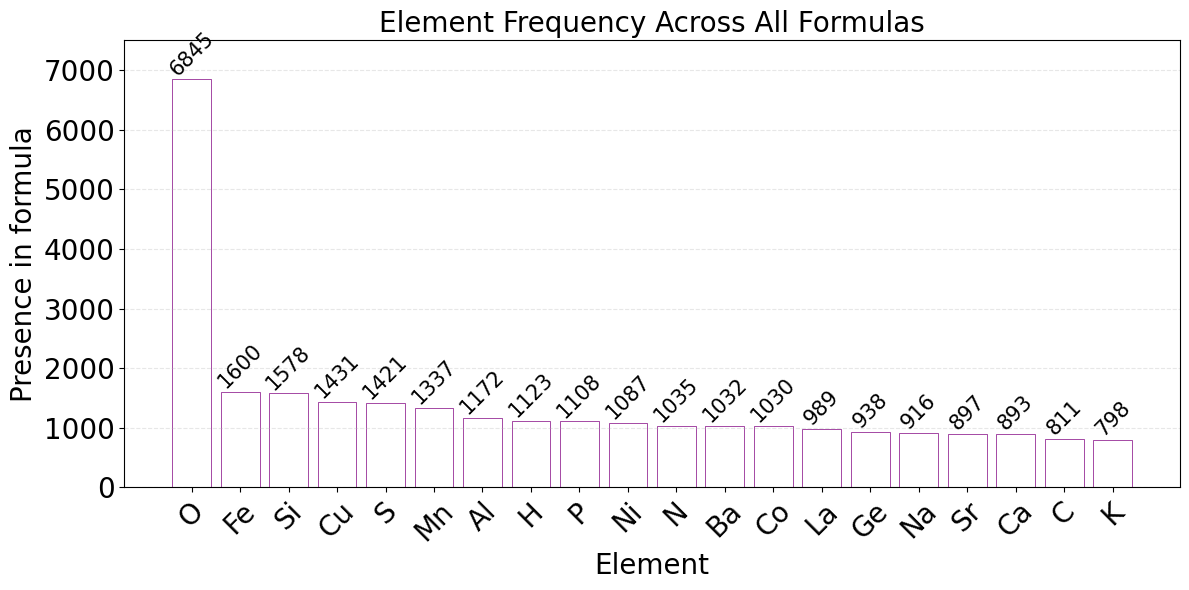

Total unique formulas: 16334
Total unique elements: 93

Top 10 most frequent elements:
O: 6845
Fe: 1600
Si: 1578
Cu: 1431
S: 1421
Mn: 1337
Al: 1172
H: 1123
P: 1108
Ni: 1087


In [6]:
import matplotlib.pyplot as plt
from collections import Counter

# Count element frequency across all unique formulas (irrespective of prototype)
all_elements = []

for formula in df['reduced_formula'].unique():
    formula_rows = df[df['reduced_formula'] == formula]
    # Get elements from first row of this formula
    elements_list = formula_rows['elements'].iloc[0]
    unique_elements = set(elements_list)
    all_elements.extend(unique_elements)

# Count element frequencies
element_counts = Counter(all_elements)
element_freq = element_counts.most_common(20)  # Top 20 elements only

# Prepare data for plotting
elements = [x[0] for x in element_freq]
counts = [x[1] for x in element_freq]

# Create bar chart
fig, ax = plt.subplots(figsize=(12, 6))
ax.set_ylim(0, 7500)
bars = ax.bar(elements, counts, color='white', edgecolor='purple', linewidth=0.5)
ax.set_xlabel('Element', fontsize=20)
ax.set_ylabel('Presence in formula', fontsize=20)
ax.set_title('Element Frequency Across All Formulas', fontsize=20)
ax.tick_params(axis='both', labelsize=20)
ax.grid(axis='y', alpha=0.3, linestyle='--')

# Add count labels on top of bars
for bar, count in zip(bars, counts):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{count}',
            ha='center', va='bottom', fontsize=15,rotation=45)

plt.xticks(rotation=45)
plt.tight_layout()
# plt.savefig('mproject_icsd_elements_bar_polymorphs.png', dpi=300, bbox_inches='tight')
plt.show()

print(f'Total unique formulas: {df["reduced_formula"].nunique()}')
print(f'Total unique elements: {len(element_counts)}')
print(f'\nTop 10 most frequent elements:')
for elem, count in element_freq[:10]:
    print(f'{elem}: {count}')

In [7]:
df_hub=df
group = [
 'Binary','Fluorite/Rutile','Perovskite','Quaternary','Rocksalt/Zincblende/CsCl','Ternary','Other']
for i in group:
    df_x=df_hub[df_hub['prototype']==i]
    formulas=df_x['reduced_formula'].unique().tolist()
    print(i,len(formulas))
    df_x=df[df_hub['prototype']==i]
    formulas=df_x['reduced_formula'].unique().tolist()
    print(i,len(formulas))
    print('\n')

Binary 2316
Binary 2316


Fluorite/Rutile 1034
Fluorite/Rutile 1034


Perovskite 410
Perovskite 410


Quaternary 3780
Quaternary 3780


Rocksalt/Zincblende/CsCl 1053
Rocksalt/Zincblende/CsCl 1053


Ternary 6486
Ternary 6486


Other 1291
Other 1291




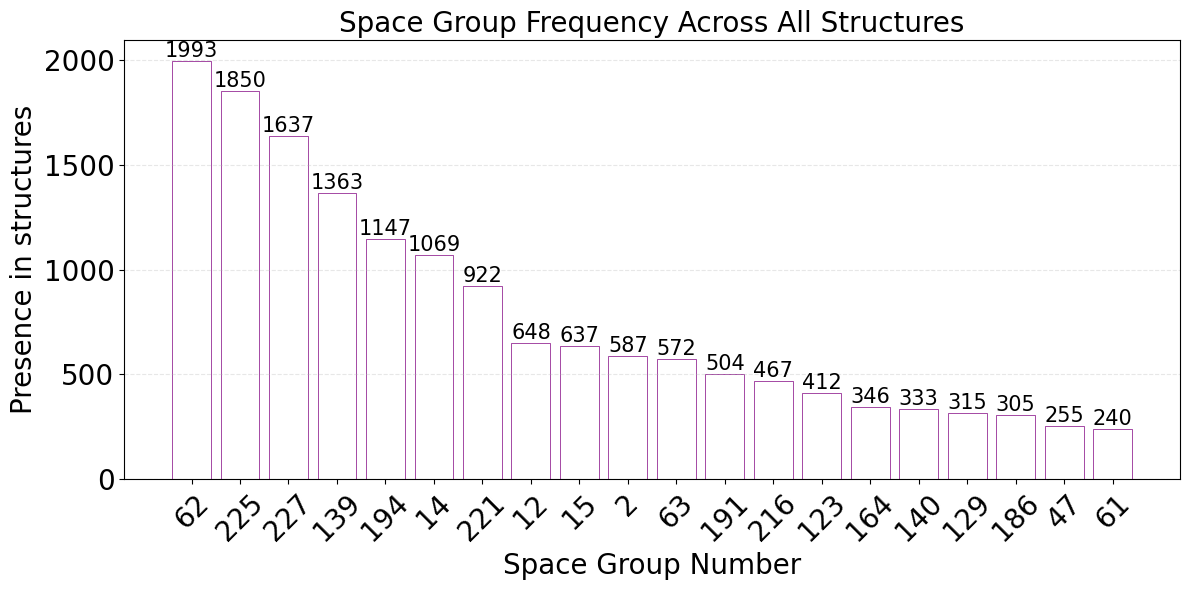

Total structures: 28785
Total unique space groups: 8769

Top 10 most frequent space groups:
SG 62.0: 1993
SG 225.0: 1850
SG 227.0: 1637
SG 139.0: 1363
SG 194.0: 1147
SG 14.0: 1069
SG 221.0: 922
SG 12.0: 648
SG 15.0: 637
SG 2.0: 587


In [8]:
import matplotlib.pyplot as plt
from collections import Counter

# Count space group frequency across all structures (all mp_id)
sg_counts = Counter(df['sg_number'])
sg_freq = sg_counts.most_common(20)  # Top 20 space groups

# Prepare data for plotting
space_groups = [str(int(x[0])) for x in sg_freq]
counts = [x[1] for x in sg_freq]

# Create bar chart
fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(space_groups, counts, color='white', edgecolor='purple', linewidth=0.5)
ax.set_xlabel('Space Group Number', fontsize=20)
ax.set_ylabel('Presence in structures', fontsize=20)
ax.set_title('Space Group Frequency Across All Structures', fontsize=20)
ax.tick_params(axis='both', labelsize=20)
ax.grid(axis='y', alpha=0.3, linestyle='--')

# Add count labels on top of bars
for bar, count in zip(bars, counts):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{count}',
            ha='center', va='bottom', fontsize=15)

plt.xticks(rotation=45)
plt.tight_layout()
# plt.savefig('mproject_icsd_sg_num_counts.png', dpi=300, bbox_inches='tight')
plt.show()

print(f'Total structures: {len(df)}')
print(f'Total unique space groups: {len(sg_counts)}')
print(f'\nTop 10 most frequent space groups:')
for sg, count in sg_freq[:10]:
    print(f'SG {sg}: {count}')

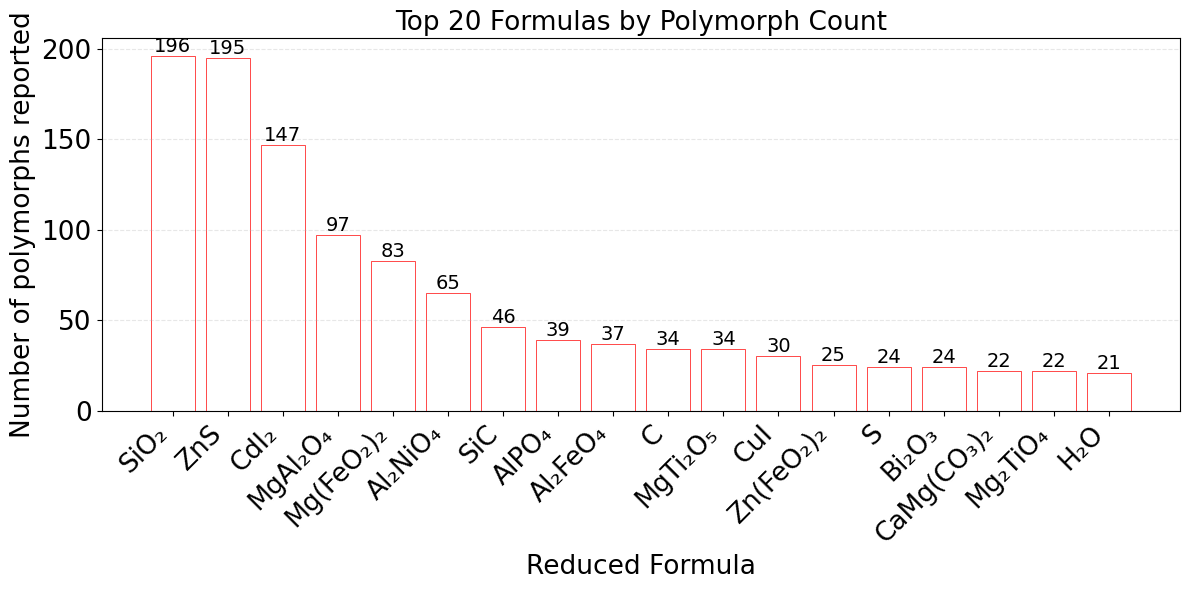

Total unique formulas: 16334

Top 18 formulas with most polymorphs:
SiO2: 196
ZnS: 195
CdI2: 147
MgAl2O4: 97
Mg(FeO2)2: 83
Al2NiO4: 65
SiC: 46
AlPO4: 39
Al2FeO4: 37
C: 34
MgTi2O5: 34
CuI: 30
Zn(FeO2)2: 25
S: 24
Bi2O3: 24
CaMg(CO3)2: 22
Mg2TiO4: 22
H2O: 21


In [9]:
import matplotlib.pyplot as plt

# Count formulas and get top 20 with most polymorphs
formula_counts = df['reduced_formula'].value_counts()
top_formulas = formula_counts.head(18)

# Prepare data for plotting
formulas = top_formulas.index.tolist()
counts = top_formulas.values.tolist()

# Convert formulas to subscript notation for display
def format_formula(formula):
    """Convert formula to subscript notation (e.g., H2O -> H₂O)"""
    import re
    # Replace digits with subscript unicode
    subscript_map = str.maketrans('0123456789', '₀₁₂₃₄₅₆₇₈₉')
    return formula.translate(subscript_map)

formulas_display = [format_formula(f) for f in formulas]

# Create bar chart
sizes=20-1
fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(range(len(formulas)), counts, color='white', edgecolor='red', linewidth=0.5)
ax.set_xlabel('Reduced Formula', fontsize=sizes)
ax.set_ylabel('Number of polymorphs reported', fontsize=sizes)
ax.set_title('Top 20 Formulas by Polymorph Count', fontsize=sizes)
ax.tick_params(axis='both', labelsize=sizes)
ax.grid(axis='y', alpha=0.3, linestyle='--')

# Set x-ticks with subscript formulas
ax.set_xticks(range(len(formulas)))
ax.set_xticklabels(formulas_display, rotation=45, ha='right')

# Add count labels on top of bars
for bar, count in zip(bars, counts):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{count}',
            ha='center', va='bottom', fontsize=14)

plt.tight_layout()
# plt.savefig('mpro_icsd_top_polymorph.png', dpi=300, bbox_inches='tight')
plt.show()

print(f'Total unique formulas: {len(formula_counts)}')
print(f'\nTop 18 formulas with most polymorphs:')
for formula, count in top_formulas.items():
    print(f'{formula}: {count}')

In [10]:
import pandas as pd
from itertools import combinations
from collections import Counter

# Step 1: Get unique sg_num values for each reduced_formula
unique_sg_per_formula = df.groupby('reduced_formula')['sg_number'].unique()

# Step 2: Find pairs of sg_num within each formula's unique list
pair_counts = Counter()

# Iterate through each formula's unique sg_num list
for sg_nums in unique_sg_per_formula:
    # Generate all pairs of space group numbers (combinations of 2)
    for pair in combinations(sorted(sg_nums), 2):
        pair_counts[pair] += 1

# Step 3: Identify the top 5 most frequent pairs
top_5_pairs = pair_counts.most_common(5)

# Display the top 5 most frequent pairs
for pair, count in top_5_pairs:
    print(f"The pair {pair} is found together in {count} formulas.")


The pair (221.0, 225.0) is found together in 104 formulas.
The pair (216.0, 225.0) is found together in 99 formulas.
The pair (194.0, 225.0) is found together in 89 formulas.
The pair (14.0, 15.0) is found together in 76 formulas.
The pair (2.0, 14.0) is found together in 67 formulas.


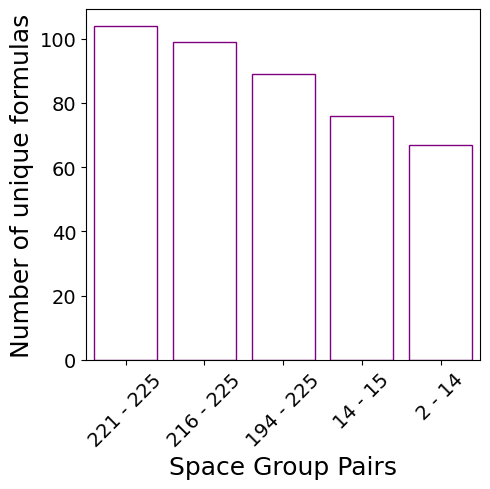

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
from collections import Counter

# Step 1: Get unique sg_num values for each reduced_formula
unique_sg_per_formula = df.groupby('reduced_formula')['sg_number'].unique()

# Step 2: Find pairs of sg_num within each formula's unique list
pair_counts = Counter()

# Iterate through each formula's unique sg_num list
for sg_nums in unique_sg_per_formula:
    # Generate all pairs of space group numbers (combinations of 2)
    for pair in combinations(sorted(sg_nums), 2):
        pair_counts[pair] += 1

# Step 3: Get the top 5 most frequent pairs
top_5_pairs = pair_counts.most_common(5)

# Step 4: Prepare data for the bar plot
pairs, counts = zip(*top_5_pairs)

# Step 5: Create bar plot
plt.figure(figsize=(5, 5))
sns.barplot(x=[f'{int(pair[0])} - {int(pair[1])}' for pair in pairs], y=counts, facecolor='white', edgecolor='purple')

# Add labels and title
plt.xlabel('Space Group Pairs', fontsize=18)
plt.ylabel('Number of unique formulas', fontsize=18)
# plt.title('Top 5 Most Frequent Space Group Pairs', fontsize=18)
plt.xticks(rotation=45, fontsize=14)
plt.yticks(fontsize=14)


# Save the plot
plt.tight_layout()
# plt.savefig('mpro_icsd_top_5_sg_pairs.png', dpi=200)

# Show the plot
plt.show()


Save the pairs for plotting

## The codes below will save the space group pairs in json for Figure 3 

In [ ]:
import numpy as np
import random
def report(a1,a2):
    pair=[]
    for i1,i2 in unique_sg_per_formula.items():
        if len(i2)>1:
            if a1 in i2 and a2 in i2:
                pair.append(i1)
    they=[]
    aas=[a1,a2]
    dic={}
    for ke in aas:
        for i in pair:
            df2=df[(df['reduced_formula']==i) & (df['sg_number']==ke)]['filename'].tolist()[0]
            they.append(df2)
        # they=['cifs/'+i for i in they]
        df4=pd.read_csv(r'../dataset/dataset_polymorphs_icsd.csv')
        # import pandas as pd
        # df=pd.read_csv('dataset/dataset_polymorphs_deduped.csv')

        df5=df4[df4['filename'].isin(they)]
        dic[str(ke)]=df5['filename'].tolist()
        print(df5['prototype'].value_counts(),df5['sg_number'].value_counts())
        print(df5['filename'].tolist()[:5],df5['sg_number'].tolist()[:5],df5['prototype'].tolist()[:5])
    return dic




In [37]:
import json

vals = list(pair_counts.items())
vals.sort(key=lambda k: k[1], reverse=True)

for i in range(15):
    a1, a2 = vals[i][0][0], vals[i][0][1]
    # print(vals[i][0], a1, a2) # a1,a2 space group pair names
    res = report(a1, a2)

    filename = f"sg_icsd_pair_{int(a1)}-{int(a2)}.json"
    with open(filename, "w") as f:
        json.dump(res, f, indent=4)

    print(f"Saved result to {filename}")
    print('**' * 20, '\n')


prototype
Rocksalt/Zincblende/CsCl    57
Ternary                     35
Spinel                       5
Quaternary                   2
Binary                       1
Name: count, dtype: int64 sg_number
216.0    100
Name: count, dtype: int64
['157431.cif', '162753.cif', '164973.cif', '108238.cif', '163467.cif'] [216.0, 216.0, 216.0, 216.0, 216.0] ['Rocksalt/Zincblende/CsCl', 'Rocksalt/Zincblende/CsCl', 'Rocksalt/Zincblende/CsCl', 'Rocksalt/Zincblende/CsCl', 'Rocksalt/Zincblende/CsCl']
prototype
Rocksalt/Zincblende/CsCl    111
Ternary                      69
Spinel                       11
Quaternary                    4
Binary                        3
Other                         1
Name: count, dtype: int64 sg_number
216.0    100
225.0     99
Name: count, dtype: int64
['157431.cif', '162753.cif', '163381.cif', '164973.cif', '182362.cif'] [216.0, 216.0, 225.0, 216.0, 225.0] ['Rocksalt/Zincblende/CsCl', 'Rocksalt/Zincblende/CsCl', 'Rocksalt/Zincblende/CsCl', 'Rocksalt/Zincblende/CsCl', 'R